In [1]:
import os
# ============================================================
# KONFIGURATION – hier alle Parameter für die Analyse anpassen
# ============================================================

# Name der Stadt – beliebige deutsche Stadt möglich
# Beispiele: "Berlin, Deutschland"
#            "München, Deutschland"
#            "Hamburg, Deutschland"
STADT = "Bonn, Deutschland"

# Projektordner – hier werden alle Daten und Karten gespeichert
BASIS = r"C:\Users\sandr\GIS_Projekte\gruenflaechen"

# Pfad zur Zensus-CSV
# Download: https://www.destatis.de/static/DE/zensus/gitterdaten/Zensus2022_Bevoelkerungszahl.zip
# Dateiname: Zensus2022_Bevoelkerungszahl_100m-Gitter.csv
ZENSUS_PATH = os.path.join(BASIS, "data", "raw",
                           "Zensus2022_Bevoelkerungszahl_100m-Gitter.csv")

# Mindestgröße der Naherholungsgebiete in Quadratmetern
# kleinere Flächen werden ignoriert
MIN_FLAECHE = 5000

# Distanzkategorien in Metern
# diese Werte bestimmen die Einfärbung beider Karten
DISTANZ_SEHR_GUT = 200   # sehr gute Versorgung
DISTANZ_GUT      = 400   # gute Versorgung
DISTANZ_MITTEL   = 600   # mittlere Versorgung
MAX_DISTANZ      = 600   # alles darüber = Index 0.0

# ============================================================

In [2]:
# Alle benötigten Bibliotheken werden hier importiert
# osmnx: lädt OpenStreetMap-Daten und Straßennetzwerke
# geopandas: verarbeitet geografische Daten (wie Polygone und Linien)
# matplotlib: erstellt Karten und Grafiken
# pandas: verarbeitet tabellarische Daten
# numpy: ermöglicht mathematische Berechnungen
# shapely: ermöglicht geometrische Berechnungen
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
import pandas as pd
from shapely.geometry import box

In [3]:
# Ausgabeordner werden erstellt falls sie noch nicht existieren
# exist_ok=True verhindert einen Fehler wenn der Ordner schon da ist
OUTPUT_DIR = os.path.join(BASIS, "outputs")
PROCESSED_DIR = os.path.join(BASIS, "data", "processed")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
print(f"✅ Ausgabeordner bereit: {OUTPUT_DIR}")

✅ Ausgabeordner bereit: C:\Users\sandr\GIS_Projekte\gruenflaechen\outputs


In [4]:
# Stadtgrenze wird als Polygon geladen
print("Lade Stadtgrenze...")
stadtgrenze = ox.geocode_to_gdf(STADT)

# Grünflächen werden anhand von OpenStreetMap-Tags geladen
print("Lade Grünflächen...")
tags = {
    "leisure": ["park", "garden", "nature_reserve"],
    "landuse": ["grass", "forest", "recreation_ground"]
}
gruenflaechen = ox.features_from_place(STADT, tags=tags)

# Nur Flächen werden behalten
gruenflaechen = gruenflaechen[
    gruenflaechen.geometry.type.isin(["Polygon", "MultiPolygon"])
].copy()
gruenflaechen = gruenflaechen.set_crs("EPSG:4326", allow_override=True)

# Hauptstraßen werden für die Kartendarstellung geladen
print("Lade Straßen...")
strassen = ox.features_from_place(
    STADT, {"highway": ["motorway", "trunk", "primary", "secondary"]})
strassen = strassen[strassen.geometry.type == "LineString"].copy()
print(f"✅ {len(strassen)} Straßenabschnitte geladen")

# Kreisfreie Städte (place_rank 12) bekommen Stadtteile/Bezirke
# Kreisangehörige Orte bekommen nur Stadtgrenze + Ortsnamen
print("Prüfe Stadttyp...")
place_rank = int(stadtgrenze["place_rank"].values[0]) if "place_rank" in stadtgrenze.columns else 16
ist_kreisfreie_stadt = place_rank <= 12
print(f"   place_rank: {place_rank} → {'Kreisfreie Stadt' if ist_kreisfreie_stadt else 'Kreisangehöriger Ort'}")

stadtteile = gpd.GeoDataFrame()
level_gefunden = None
verwaltungseinheit = None

if ist_kreisfreie_stadt:
    print("Lade Verwaltungseinheiten...")
    alle_grenzen = ox.features_from_place(STADT, {"boundary": "administrative"})

    for level in [10, 9, 8]:
        kandidaten_poly = alle_grenzen[
            (alle_grenzen.geometry.type.isin(["Polygon", "MultiPolygon"])) &
            (alle_grenzen["admin_level"].astype(str) == str(level))
        ].copy()

        kandidaten_punkt = alle_grenzen[
            (alle_grenzen.geometry.type == "Point") &
            (alle_grenzen["admin_level"].astype(str) == str(level))
        ].copy()

        kandidaten = pd.concat([kandidaten_poly, kandidaten_punkt])
        if len(kandidaten) == 0:
            continue

        kandidaten = gpd.GeoDataFrame(kandidaten, crs="EPSG:4326")

        kandidaten_proj = kandidaten.to_crs("EPSG:25832")
        stadtgrenze_proj = stadtgrenze.to_crs("EPSG:25832").union_all()
        maske = kandidaten_proj.geometry.centroid.within(stadtgrenze_proj)
        kandidaten = kandidaten[maske].copy()

        if len(kandidaten) >= 2:
            stadtteile = kandidaten
            level_gefunden = level
            hat_polygone = kandidaten.geometry.type.isin(
                ["Polygon", "MultiPolygon"]).any()
            print(f"   Verwaltungsebene {level} gefunden: {len(stadtteile)} Einträge")
            if not hat_polygone:
                print(f"   ⚠️ Nur Punkte gefunden – Namen werden angezeigt, keine Grenzen")
            break

    if level_gefunden == 10:
        verwaltungseinheit = "Stadtteile"
    elif level_gefunden == 9:
        verwaltungseinheit = "Stadtbezirke"
    elif level_gefunden == 8:
        verwaltungseinheit = "Ortsteile"
    elif level_gefunden is None:
        print("   ⚠️ Keine Verwaltungseinheiten gefunden – Karte ohne Grenzen")

if verwaltungseinheit:
    print(f"✅ {len(stadtteile)} {verwaltungseinheit} geladen")
else:
    print("✅ Stadtgrenze geladen – keine Verwaltungseinheiten")



Lade Stadtgrenze...
Lade Grünflächen...
Lade Straßen...
✅ 1675 Straßenabschnitte geladen
Prüfe Stadttyp...
   place_rank: 12 → Kreisfreie Stadt
Lade Verwaltungseinheiten...
   Verwaltungsebene 10 gefunden: 51 Einträge
✅ 51 Stadtteile geladen


In [5]:
# Die Grünflächen werden ins metrische System projiziert
# damit die Flächenberechnung in Quadratmetern funktioniert
gruenflaechen_proj = gruenflaechen.to_crs("EPSG:25832").copy()

# Die Fläche jeder Grünfläche wird in Quadratmetern berechnet
gruenflaechen_proj["flaeche_m2"] = gruenflaechen_proj.geometry.area

# Alle relevanten Grünflächen werden zu einem einzigen Layer zusammengeführt
# Wälder, Parks und Naturschutzgebiete über MIN_FLAECHE Quadratmeter
relevante_typen = gruenflaechen_proj[
    (
        gruenflaechen_proj.get("landuse", pd.Series()).isin(["forest"]) |
        gruenflaechen_proj.get("leisure", pd.Series()).isin(["park", "nature_reserve"])
    ) &
    (gruenflaechen_proj["flaeche_m2"] > MIN_FLAECHE)
].copy()
relevante_typen["kategorie"] = "Naherholungsgebiet"

print(f"✅ {len(relevante_typen)} Naherholungsgebiete > {MIN_FLAECHE:,} m² gefunden")

✅ 238 Naherholungsgebiete > 5,000 m² gefunden


In [6]:
# Alle relevanten Grünflächen werden zu einer einzigen Geometrie zusammengeführt
# die Distanz wird dann zur Außengrenze dieser Gesamtfläche gemessen
print("Bereite Grünflächen vor...")
gruenflaechen_gesamt = relevante_typen.geometry.union_all()

# Stadtgrenze ins metrische System projizieren
stadt_25832 = stadtgrenze.to_crs("EPSG:25832")

# Zensus-Daten laden
print("Lade Zensus-Daten...")
zensus = pd.read_csv(ZENSUS_PATH, sep=";", encoding="utf-8")

# Einwohner=-1 bedeutet "keine Angabe" und wird entfernt
zensus_clean = zensus[zensus["Einwohner"] > 0].copy()

# Aus den x/y Spalten werden Punkt-Geometrien erstellt
# die Koordinaten sind im europäischen System EPSG:3035
zensus_gdf = gpd.GeoDataFrame(
    zensus_clean,
    geometry=gpd.points_from_xy(zensus_clean["x_mp_100m"],
                                 zensus_clean["y_mp_100m"]),
    crs="EPSG:3035"
).to_crs("EPSG:25832")

# Nur Rasterzellen innerhalb der Stadt werden behalten
print("Schneide auf Stadtgebiet zu...")
zensus_stadt = gpd.clip(zensus_gdf, stadt_25832).copy()
print(f"✅ {len(zensus_stadt)} Rasterzellen im Stadtgebiet")

# Für jede Rasterzelle wird die Luftliniendistanz zur nächsten
# Grünfläche berechnet – gemessen zur Außengrenze des Polygons
print("Berechne Distanzen zur nächsten Grünfläche...")
zensus_stadt["distanz_m"] = zensus_stadt.geometry.distance(gruenflaechen_gesamt)
print(f"✅ Maximale Distanz: {zensus_stadt['distanz_m'].max():.0f}m")
print(f"   Mittlere Distanz: {zensus_stadt['distanz_m'].mean():.0f}m")

Bereite Grünflächen vor...
Lade Zensus-Daten...
Schneide auf Stadtgebiet zu...
✅ 5456 Rasterzellen im Stadtgebiet
Berechne Distanzen zur nächsten Grünfläche...
✅ Maximale Distanz: 995m
   Mittlere Distanz: 244m


In [7]:
# Dateiname wird aus dem Stadtnamen abgeleitet
stadtname = STADT.split(",")[0].strip().lower().replace(" ", "_")

# Versorgungsindex wird linear normalisiert
# 0m = Index 1.0 (bestens versorgt), MAX_DISTANZ = Index 0.0 (unversorgt)
zensus_stadt["versorgungsindex"] = (
    1 - (zensus_stadt["distanz_m"] / MAX_DISTANZ)
).clip(0, 1)

# Jede Person wird mit ihrem Versorgungsindex gewichtet
zensus_stadt["gewichtete_versorgung"] = (
    zensus_stadt["versorgungsindex"] * zensus_stadt["Einwohner"]
)

einwohner_gesamt = zensus_stadt["Einwohner"].sum()
versorgungsquote = zensus_stadt["gewichtete_versorgung"].sum() / einwohner_gesamt * 100

# Kategorien basierend auf den konfigurierten Distanzgrenzen
sehr_gut = zensus_stadt[
    zensus_stadt["distanz_m"] <= DISTANZ_SEHR_GUT]["Einwohner"].sum()
gut = zensus_stadt[
    (zensus_stadt["distanz_m"] > DISTANZ_SEHR_GUT) &
    (zensus_stadt["distanz_m"] <= DISTANZ_GUT)]["Einwohner"].sum()
mittel = zensus_stadt[
    (zensus_stadt["distanz_m"] > DISTANZ_GUT) &
    (zensus_stadt["distanz_m"] <= DISTANZ_MITTEL)]["Einwohner"].sum()
weniger_gut = zensus_stadt[
    zensus_stadt["distanz_m"] > DISTANZ_MITTEL]["Einwohner"].sum()

# Flächenbasierte Versorgungsquote zum Vergleich
gruenflaechen_puffer = gruenflaechen_gesamt.buffer(500)
schnitt = gruenflaechen_puffer.intersection(stadt_25832.geometry.iloc[0])
anteil = schnitt.area / stadt_25832.geometry.iloc[0].area * 100

print(f"📊 Ergebnisse für {STADT}:")
print(f"   Gewichteter Versorgungsindex:  {versorgungsquote:.1f}%")
print(f"   Flächenbasiert (500m Puffer):  {anteil:.1f}% der Stadtfläche")
print(f"")
print(f"   Sehr gut  (0-{DISTANZ_SEHR_GUT}m):   {sehr_gut:,} Einwohner ({sehr_gut/einwohner_gesamt*100:.1f}%)")
print(f"   Gut       ({DISTANZ_SEHR_GUT}-{DISTANZ_GUT}m): {gut:,} Einwohner ({gut/einwohner_gesamt*100:.1f}%)")
print(f"   Mittel    ({DISTANZ_GUT}-{DISTANZ_MITTEL}m): {mittel:,} Einwohner ({mittel/einwohner_gesamt*100:.1f}%)")
print(f"   Wenig     (>{DISTANZ_MITTEL}m):    {weniger_gut:,} Einwohner ({weniger_gut/einwohner_gesamt*100:.1f}%)")

📊 Ergebnisse für Bonn, Deutschland:
   Gewichteter Versorgungsindex:  55.2%
   Flächenbasiert (500m Puffer):  92.7% der Stadtfläche

   Sehr gut  (0-200m):   139,028 Einwohner (43.3%)
   Gut       (200-400m): 100,726 Einwohner (31.3%)
   Mittel    (400-600m): 51,129 Einwohner (15.9%)
   Wenig     (>600m):    30,468 Einwohner (9.5%)


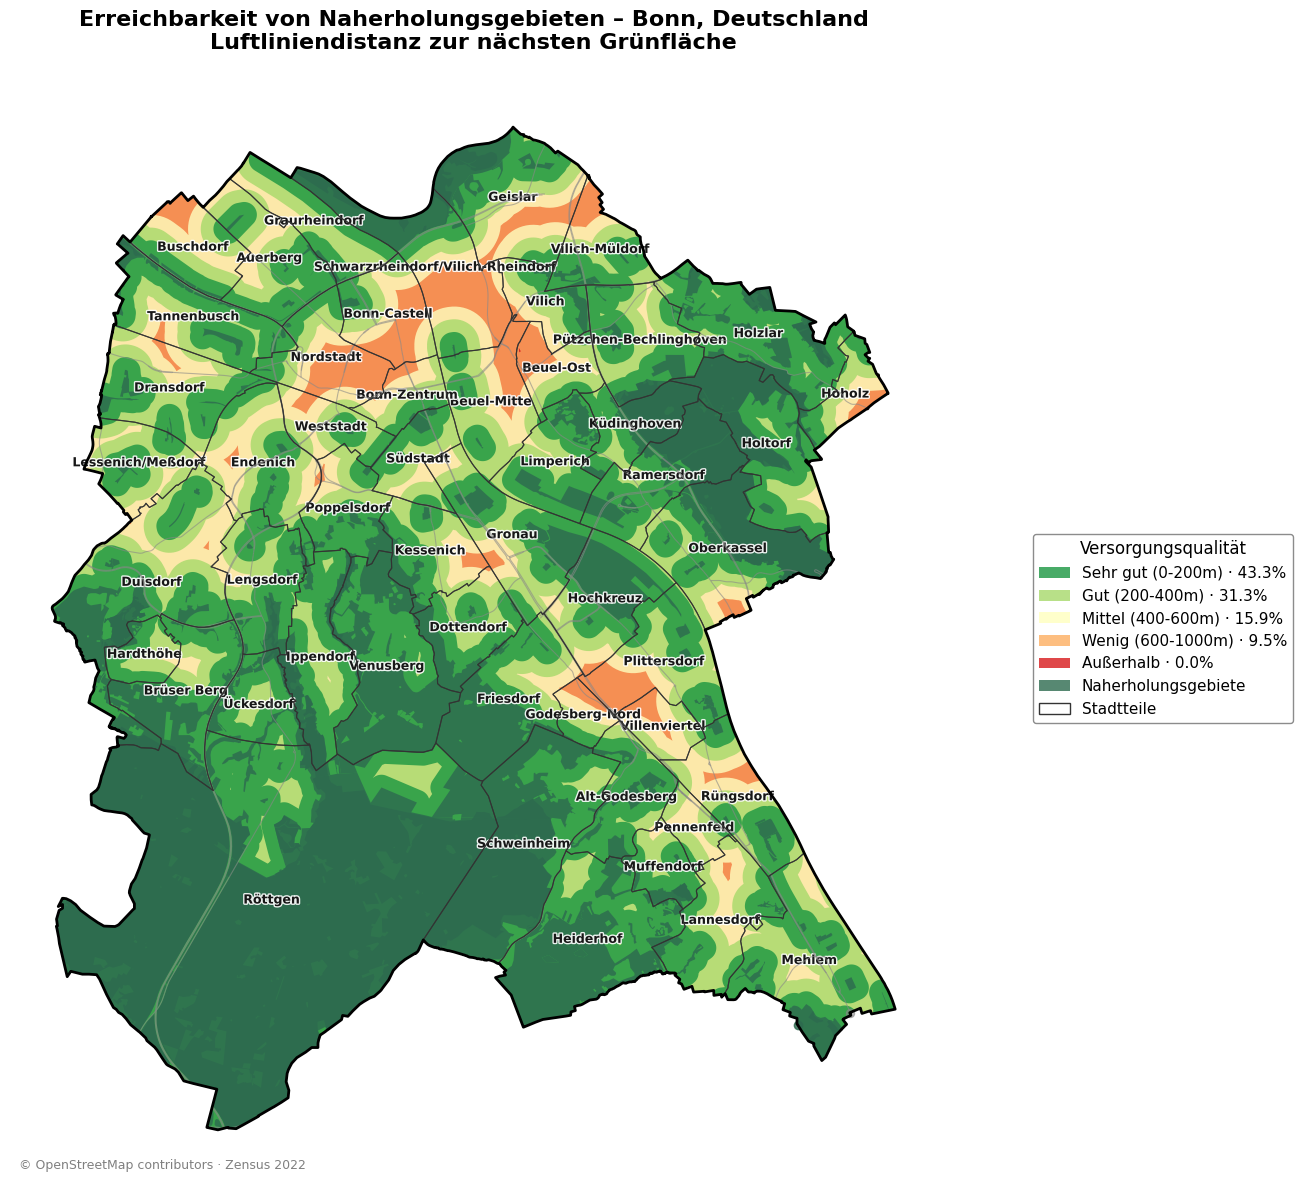

✅ Erreichbarkeitskarte gespeichert


In [8]:
# Stadtgrenze und Clips vorbereiten
stadtgrenze_4326 = stadtgrenze.to_crs("EPSG:4326")
naherholung_clip = relevante_typen.to_crs("EPSG:4326").clip(stadtgrenze_4326)

# Distanzzonen als konzentrische Puffer
zonen = [
    (DISTANZ_SEHR_GUT, "#1a9641", f"Sehr gut (0-{DISTANZ_SEHR_GUT}m) · {sehr_gut/einwohner_gesamt*100:.1f}%"),
    (DISTANZ_GUT,      "#a6d96a", f"Gut ({DISTANZ_SEHR_GUT}-{DISTANZ_GUT}m) · {gut/einwohner_gesamt*100:.1f}%"),
    (DISTANZ_MITTEL,   "#ffffbf", f"Mittel ({DISTANZ_GUT}-{DISTANZ_MITTEL}m) · {mittel/einwohner_gesamt*100:.1f}%"),
    (1000,             "#fdae61", f"Wenig ({DISTANZ_MITTEL}-1000m) · {weniger_gut/einwohner_gesamt*100:.1f}%"),
]

fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(1, 2, width_ratios=[4, 1])
ax = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])
ax_legend.set_axis_off()

# Schicht 1: Hintergrund in der Farbe der schlechtesten Zone
stadtgrenze_4326.plot(ax=ax, color="#d7191c", edgecolor="none", zorder=1)

# Schicht 2: Distanzzonen von außen nach innen
for distanz, farbe, label in reversed(zonen):
    puffer = gruenflaechen_gesamt.buffer(distanz)
    puffer_gdf = gpd.GeoDataFrame(
        geometry=[puffer], crs="EPSG:25832"
    ).to_crs("EPSG:4326").clip(stadtgrenze_4326)
    puffer_gdf.plot(ax=ax, color=farbe, alpha=0.8, zorder=2)

# Schicht 3: Naherholungsgebiete als grüne Flächen
naherholung_clip.plot(ax=ax, color="#2d6a4f", alpha=0.8, zorder=3)

# Schicht 4: Hauptstraßen
strassen.to_crs("EPSG:4326").clip(stadtgrenze_4326).plot(
    ax=ax, color="#888888", linewidth=0.8, alpha=0.6, zorder=4)

# Schicht 5: Verwaltungseinheiten als Grenzen
if verwaltungseinheit:
    stadtteile_clip = stadtteile.to_crs("EPSG:4326").clip(stadtgrenze_4326)
    poly_mask = stadtteile_clip.geometry.type.isin(["Polygon", "MultiPolygon"])
    if poly_mask.any():
        stadtteile_clip[poly_mask].plot(ax=ax, color="none",
            edgecolor="#333333", linewidth=0.8, alpha=0.9, zorder=5)

# Schicht 6: Stadtgrenze
stadtgrenze_4326.plot(ax=ax, color="none", edgecolor="black", linewidth=2, zorder=6)

# Legende
legende = [
    Patch(facecolor="#1a9641", alpha=0.8, label=f"Sehr gut (0-{DISTANZ_SEHR_GUT}m) · {sehr_gut/einwohner_gesamt*100:.1f}%"),
    Patch(facecolor="#a6d96a", alpha=0.8, label=f"Gut ({DISTANZ_SEHR_GUT}-{DISTANZ_GUT}m) · {gut/einwohner_gesamt*100:.1f}%"),
    Patch(facecolor="#ffffbf", alpha=0.8, label=f"Mittel ({DISTANZ_GUT}-{DISTANZ_MITTEL}m) · {mittel/einwohner_gesamt*100:.1f}%"),
    Patch(facecolor="#fdae61", alpha=0.8, label=f"Wenig ({DISTANZ_MITTEL}-1000m) · {weniger_gut/einwohner_gesamt*100:.1f}%"),
    Patch(facecolor="#d7191c", alpha=0.8, label="Außerhalb · 0.0%"),
    Patch(facecolor="#2d6a4f", alpha=0.8, label="Naherholungsgebiete"),
]
if verwaltungseinheit:
    legende.append(
        Patch(facecolor="none", edgecolor="#333333",
              label=verwaltungseinheit)
    )

ax_legend.legend(handles=legende, fontsize=11, loc="center",
          framealpha=0.9, edgecolor="gray",
          title="Versorgungsqualität", title_fontsize=12)

ax.set_title(
    f"Erreichbarkeit von Naherholungsgebieten – {STADT}\n"
    f"Luftliniendistanz zur nächsten Grünfläche",
    fontsize=16, fontweight="bold", pad=20)
ax.set_axis_off()
ax.annotate("© OpenStreetMap contributors · Zensus 2022",
            xy=(0.01, 0.01), xycoords="axes fraction",
            fontsize=9, color="gray")

# Verwaltungseinheiten-Namen ganz am Ende
if verwaltungseinheit:
    for idx, row in stadtteile_clip.iterrows():
        punkt = row.geometry.centroid
        if pd.isna(row.get("name", None)):
            continue
        ax.annotate(
            text=row["name"],
            xy=(punkt.x, punkt.y),
            fontsize=9, color="black", alpha=0.9,
            ha="center", va="center", fontweight="bold",
            path_effects=[pe.withStroke(linewidth=2, foreground="white")]
        )


plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{stadtname}_erreichbarkeit.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Erreichbarkeitskarte gespeichert")

Erstelle Rasterzellen-Polygone...
✅ 5456 Rasterzellen erstellt


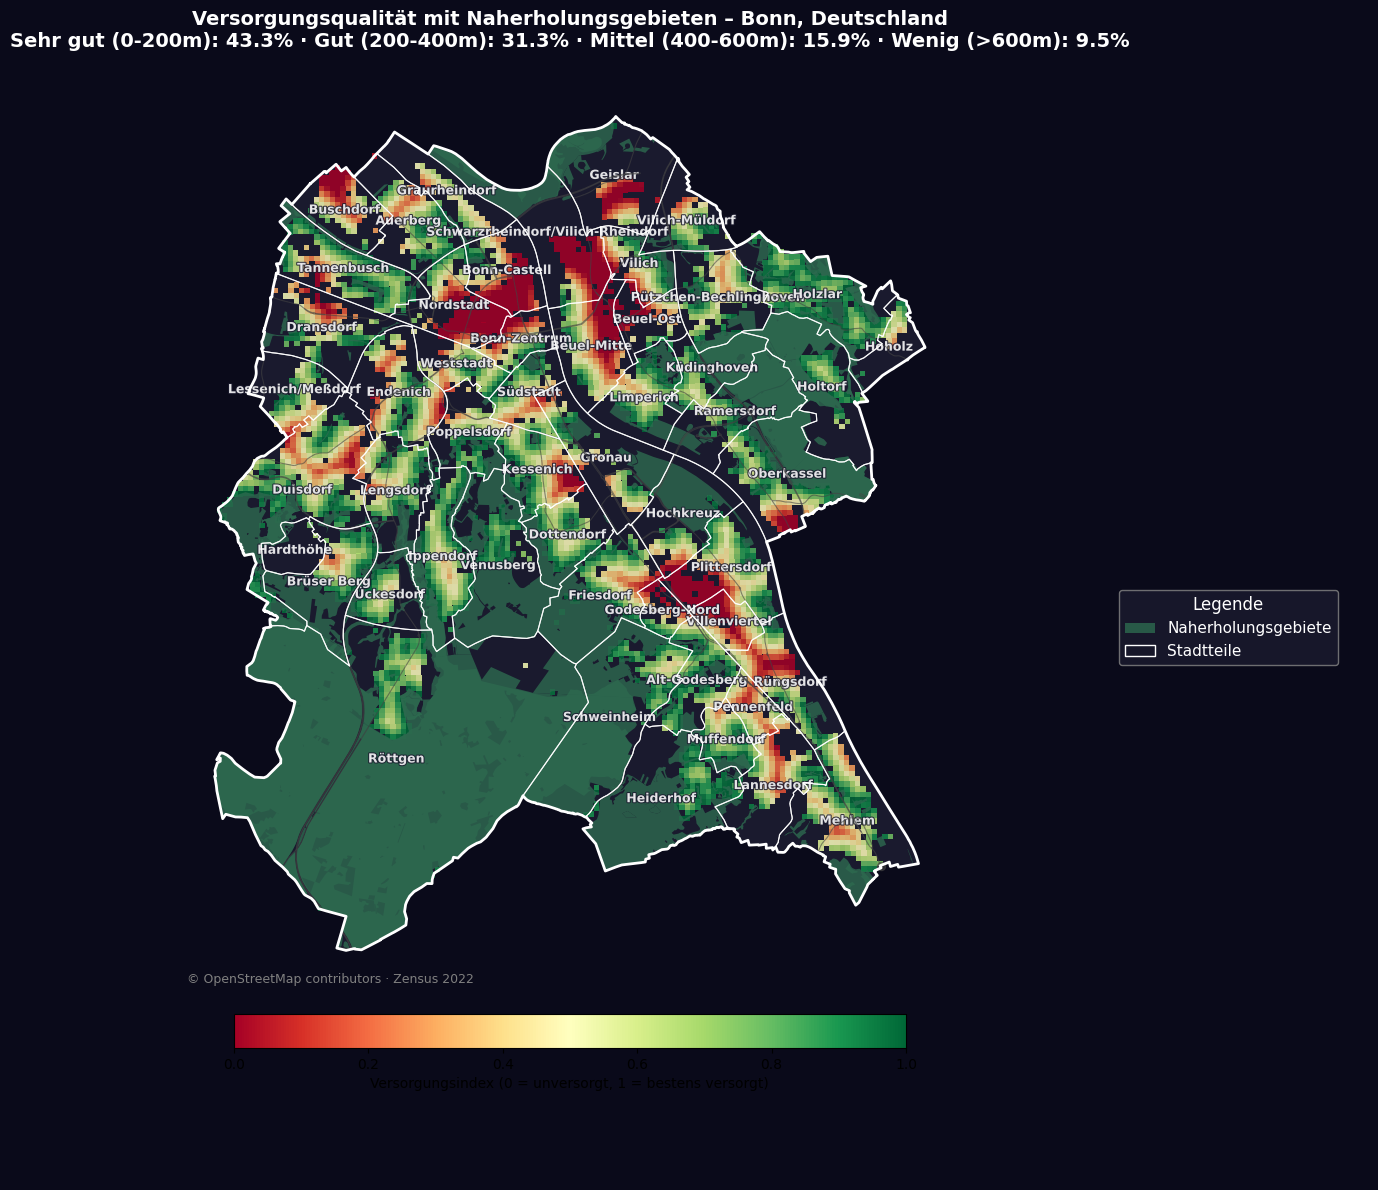

✅ Bevölkerungskarte gespeichert


In [9]:
# Rasterzellen werden in quadratische Polygone umgewandelt
print("Erstelle Rasterzellen-Polygone...")

def punkt_zu_zelle(punkt):
    x, y = punkt.x, punkt.y
    return box(x - 50, y - 50, x + 50, y + 50)

zensus_stadt["zelle"] = zensus_stadt.geometry.apply(punkt_zu_zelle)
zensus_poly = zensus_stadt.set_geometry("zelle")
print(f"✅ {len(zensus_poly)} Rasterzellen erstellt")

fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(1, 2, width_ratios=[4, 1])
ax = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])
ax_legend.set_axis_off()

fig.patch.set_facecolor("#0a0a1a")
ax.set_facecolor("#0a0a1a")

# Schicht 1: Stadtfläche als dunkler Hintergrund
stadtgrenze.to_crs("EPSG:25832").plot(
    ax=ax, color="#1a1a2e", edgecolor="none", zorder=1)

# Schicht 2: Rasterzellen eingefärbt nach Versorgungsindex
zensus_poly.plot(
    ax=ax,
    column="versorgungsindex",
    cmap="RdYlGn",
    vmin=0, vmax=1,
    alpha=0.85,
    zorder=2,
    legend=True,
    legend_kwds={
        "label": "Versorgungsindex (0 = unversorgt, 1 = bestens versorgt)",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.02
    }
)

# Schicht 3: Naherholungsgebiete als grüne Flächen
relevante_typen.to_crs("EPSG:25832").clip(stadt_25832).plot(
    ax=ax, color="#2d6a4f", alpha=0.8, zorder=3)

# Schicht 4: Hauptstraßen
strassen.to_crs("EPSG:25832").clip(stadt_25832).plot(
    ax=ax, color="#444444", linewidth=0.8, alpha=0.6, zorder=4)

# Schicht 5: Verwaltungseinheiten als Grenzen
if verwaltungseinheit:
    poly_mask = stadtteile.geometry.type.isin(["Polygon", "MultiPolygon"])
    if poly_mask.any():
        stadtteile[poly_mask].to_crs("EPSG:25832").clip(stadt_25832).plot(
            ax=ax, color="none", edgecolor="white",
            linewidth=0.8, alpha=0.9, zorder=5)

# Schicht 6: Stadtgrenze
stadtgrenze.to_crs("EPSG:25832").plot(
    ax=ax, color="none", edgecolor="white", linewidth=2, zorder=6)

# Legende
legende = [
    Patch(facecolor="#2d6a4f", alpha=0.8, label="Naherholungsgebiete"),
]
if verwaltungseinheit:
    legende.append(
        Patch(facecolor="none", edgecolor="white",
              label=verwaltungseinheit)
    )

leg = ax_legend.legend(handles=legende, fontsize=11, loc="center",
          framealpha=0.85, facecolor="#1a1a2e", edgecolor="gray",
          labelcolor="white", title="Legende", title_fontsize=12)
leg.get_title().set_color("white")

ax.set_title(
    f"Versorgungsqualität mit Naherholungsgebieten – {STADT}\n"
    f"Sehr gut (0-{DISTANZ_SEHR_GUT}m): {sehr_gut/einwohner_gesamt*100:.1f}% · "
    f"Gut ({DISTANZ_SEHR_GUT}-{DISTANZ_GUT}m): {gut/einwohner_gesamt*100:.1f}% · "
    f"Mittel ({DISTANZ_GUT}-{DISTANZ_MITTEL}m): {mittel/einwohner_gesamt*100:.1f}% · "
    f"Wenig (>{DISTANZ_MITTEL}m): {weniger_gut/einwohner_gesamt*100:.1f}%",
    fontsize=14, fontweight="bold", pad=20, color="white")
ax.set_axis_off()
ax.annotate("© OpenStreetMap contributors · Zensus 2022",
            xy=(0.01, 0.01), xycoords="axes fraction",
            fontsize=9, color="gray")

# Verwaltungseinheiten-Namen ganz am Ende
if verwaltungseinheit:
    for idx, row in stadtteile.to_crs("EPSG:25832").iterrows():
        punkt = row.geometry.centroid
        if pd.isna(row.get("name", None)):
            continue
        ax.annotate(
            text=row["name"],
            xy=(punkt.x, punkt.y),
            fontsize=9, color="white", alpha=0.85,
            ha="center", va="center", fontweight="bold",
            path_effects=[pe.withStroke(linewidth=1.5, foreground="#1a1a2e")]
        )


plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{stadtname}_bevoelkerung.png"),
            dpi=300, bbox_inches="tight", facecolor="#0a0a1a")
plt.show()
print("✅ Bevölkerungskarte gespeichert")

In [10]:
def bereinige_geodataframe(gdf):
    # GeoPackage unterstützt nur eine Geometriespalte pro Layer
    # zusätzliche Geometriespalten werden daher entfernt
    geo_spalten = gdf.select_dtypes(include="geometry").columns.tolist()
    geo_spalten.remove("geometry")
    return gdf.drop(columns=geo_spalten, errors="ignore").copy()

# Alle Layer werden in einem einzigen GeoPackage gespeichert
gpkg_pfad = os.path.join(PROCESSED_DIR, f"{stadtname}_analyse.gpkg")

stadtgrenze.to_file(gpkg_pfad, layer="stadtgrenze", driver="GPKG")

gruenflaechen.to_crs("EPSG:25832").pipe(bereinige_geodataframe).to_file(
    gpkg_pfad, layer="gruenflaechen", driver="GPKG")

relevante_typen.pipe(bereinige_geodataframe).to_file(
    gpkg_pfad, layer="naherholungsgebiete", driver="GPKG")

zensus_stadt.pipe(bereinige_geodataframe).to_file(
    gpkg_pfad, layer="zensus", driver="GPKG")

print(f"✅ Alle Daten gespeichert in data/processed/{stadtname}_analyse.gpkg")

✅ Alle Daten gespeichert in data/processed/bonn_analyse.gpkg
